# Cardiac Pathology Prediction (IMA205 Challenge 2025)
## Mariana OLM REZENDE

### Index
[1. Introduction](#introduction)  
[2. Importing packages and data](#importing-packages-and-data)  
[3. Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)  
[4. Missing Segmentation (LV)](#lv-segmentation)  
[5. Metrics and Features](#metrics-and-features)  
[6. Model](#model)  
[7. Conclusion](#conclusion)  
[8. References](#ref)

# 1. Introduction <a name="introduction"></a>


Cardiac function analysis is a vital part of clinical cardiology, crucial for diagnosing heart diseases, managing patient care, and making informed treatment decisions. This challenge focuses on four cardiac conditions that may go undetected in the early stages but can become life-threatening if not caught in time. These conditions can lead to serious complications, including heart failure and sudden cardiac arrest.

Identifying these issues early is key to preventing further health problems and ensuring effective treatment. In recent years, cardiac magnetic resonance imaging (CMRI) has been increasingly used to help diagnose these conditions, offering a non-invasive way to detect and assess cardiac pathologies.

The goal of the challenge is to classify subjects based on their CMRI exams among five different diagnostic classes:

0. Healthy controls (NOR)
1. Myocardial infarction (MINF)
2. Dilated cardiomyopathy (DCM)
3. Hypertrophic cardiomyopathy (HCM)
4. Abnormal right ventricle (ARV)

# 2. Importing packages, functions and data <a name="importing-packages-and-data"></a>

## Packages

In [1]:
import importlib
import pandas as pd
import ipywidgets as widgets
import numpy as np
import random

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import os
import nibabel as nib

from scipy.ndimage import binary_fill_holes
from scipy.spatial import distance

import skimage
from skimage.morphology import convex_hull_image
from skimage.measure import label, regionprops

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import cv2

In [2]:
libraries = [
    'numpy', 'pandas', 'scipy', 'sklearn', 'joblib',
    'matplotlib', 'seaborn', 'nibabel', 'skimage', 'cv2'
]

records = []

for lib in libraries:
    try:
        module = importlib.import_module(lib)
        version = module.__version__
    except ImportError:
        version = 'Not installed'
    records.append({"Library": lib, "Version": version})

df = pd.DataFrame(records)
display(widgets.Output())
display(df.style.set_table_attributes("style='display:inline'").set_caption("Library Versions"))

Output()

,Library,Version
0,numpy,2.2.4
1,pandas,2.2.3
2,scipy,1.15.2
3,sklearn,1.6.1
4,joblib,1.4.2
5,matplotlib,3.10.1
6,seaborn,0.13.2
7,nibabel,5.3.2
8,skimage,0.25.2
9,cv2,4.11.0


## Functions

In [3]:
def data_to_dict(path):
    """
    Loads ED, ES, and their segmentations for each subject folder inside path.

    Returns:
        data_dict: A dictionary of the form:
            data_dict[subject_name] = {
                'ED': nib.Nifti1Image,
                'ES': nib.Nifti1Image,
                'ED_seg': nib.Nifti1Image,
                'ES_seg': nib.Nifti1Image
            }
    """
    
    data_dict = {}

    # Iterate over all folders in the specified directory
    for subject_folder in os.listdir(path):
        subject_path = os.path.join(path, subject_folder)
        
        if os.path.isdir(subject_path):
            # Construct file paths for ED, ES, and segmentations
            ed_path     = os.path.join(subject_path, f"{subject_folder}_ED.nii")
            es_path     = os.path.join(subject_path, f"{subject_folder}_ES.nii")
            ed_seg_path = os.path.join(subject_path, f"{subject_folder}_ED_seg.nii")
            es_seg_path = os.path.join(subject_path, f"{subject_folder}_ES_seg.nii")
            
            # Check if all files exist
            if all(os.path.isfile(path) for path in [ed_path, es_path, ed_seg_path, es_seg_path]):
                # Load the NIfTI images using nibabel
                ed_img     = nib.load(ed_path)
                es_img     = nib.load(es_path)
                ed_seg_img = nib.load(ed_seg_path)
                es_seg_img = nib.load(es_seg_path)

                # Store images in the dictionary
                data_dict[subject_folder] = {
                    'ED': ed_img,
                    'ES': es_img,
                    'ED_seg': ed_seg_img,
                    'ES_seg': es_seg_img
                }

    return data_dict

def get_volumetric_image(subject_data):
    """
    Extracts the ED, ES, and their segmentations from the given subject data.

    Returns:
        ed_img, es_img, ed_seg, es_seg: 3D numpy arrays representing the ED, ES images and their segmentations.
    """
    ed_img = subject_data['ED'].get_fdata()
    es_img = subject_data['ES'].get_fdata()
    ed_seg = subject_data['ED_seg'].get_fdata()
    es_seg = subject_data['ES_seg'].get_fdata()

    return ed_img, es_img, ed_seg, es_seg

def get_header(subject_data):
    """
    Extracts the header information from the ED, ES, and their segmentations for a given subject.

    Returns:
        ed_header, es_header, ed_seg_header, es_seg_header: Header information for the respective images.
    """
    ed_header = subject_data['ED'].header
    es_header = subject_data['ES'].header
    ed_seg_header = subject_data['ED_seg'].header
    es_seg_header = subject_data['ES_seg'].header

    return ed_header, es_header, ed_seg_header, es_seg_header

def compute_iou(pred, true, label):
    """
    Compute Intersection over Union (IoU) for a given label in the predicted and true segmentation masks.
    
    Returns a tuple (dice, iou).
    """
    
    pred_mask = (pred == label)
    true_mask = (true == label)
    
    # Calculate the intersection and union
    intersection = np.sum(pred_mask & true_mask)
    union = np.sum(pred_mask | true_mask)
    
    # Compute IoU (avoid division by zero)
    iou = intersection / union if union > 0 else 1.0

    return iou

def fill_lv_inside_myo(seg_3d, myo_label=2, lv_label=3):
    """
    Fills the inside of the myocardium (myo_label) with the LV label (lv_label) 
    on slices of a 3D segmentation volume.

    Parameters:
        seg_3d (ndarray): 3D segmentation volume.
        myo_label (int): Label for myocardium.
        lv_label (int): Label for left ventricle.

    Returns:
        ndarray: Modified 3D segmentation with filled LV inside myocardium.
    """
    seg_filled = seg_3d.copy()
    seg_filled[seg_filled==3] = 0 # background
    
    # Process each slice independently
    for z in range(seg_filled.shape[-1]):
        slice_data = seg_filled[:,:, z]
        
        # Only process slices that contain any Myocardium
        if np.any(slice_data == myo_label):
            myo_mask = (slice_data == myo_label)

            # Fill enclosed holes in myocardium
            filled_myo = binary_fill_holes(myo_mask)

            # Identify filled-in regions and assign LV label to these regions
            new_lv_area = filled_myo & ~myo_mask 
                
            slice_data[new_lv_area] = lv_label         
            seg_filled[..., z] = slice_data     

    return seg_filled


def solution_lv_inside_myo(seg_3d, myo_label=2, lv_label=3):
    """
    Fills the inside of the myocardium (myo_label) with the LV label (lv_label) 
    on slices of a 3D segmentation volume using convex hull filling.

    Parameters:
        seg_3d (ndarray): 3D segmentation volume.
        myo_label (int): Label for myocardium.
        lv_label (int): Label for left ventricle.

    Returns:
        ndarray: Modified 3D segmentation with filled LV inside myocardium.
    """
    seg_filled = seg_3d.copy()
    seg_filled[seg_filled==lv_label] = 0  # Reset any LV label to background
    
    # Process each slice independently
    for z in range(seg_filled.shape[-1]):
        slice_data = seg_filled[:, :, z]
        
        # Only process slices that contain any Myocardium
        if np.any(slice_data == myo_label):
            myo_mask = (slice_data == myo_label)

            # Use convex hull on the myocardium
            convex_myo = convex_hull_image(myo_mask)

            # Identify filled-in regions inside myocardium
            new_lv_area = convex_myo & ~myo_mask 

            # Keep only the largest connected component in new_lv_area
            labeled_area = skimage.measure.label(new_lv_area)
            
            if labeled_area.max() > 0:
                regions = regionprops(labeled_area)
                largest_region = max(regions, key=lambda r: r.area)
                largest_mask = (labeled_area == largest_region.label)
            else:
                largest_mask = new_lv_area

            slice_data[largest_mask] = lv_label
            seg_filled[:, :, z] = slice_data

    return seg_filled

def compute_volume(list_keys, data_part, label):
    """
    Computes the volume of a specific label in both the ED and ES segmentations.
    
    Parameters:
        list_keys: List of subject indices.
        data_part: 'train' or 'test' to specify the dataset.
        label: The label for which the volume is computed.

    Returns:
        vol_ed, vol_es: Lists of volumes for ED and ES for each subject.
    """
    
    vol_ed = []
    vol_es = []

    if data_part == 'train':
        nift_dict = nifti_train_dict
        voxel_volumes = voxel_volumes_train
        
    elif data_part == 'test':
        nift_dict = nifti_test_dict
        voxel_volumes = voxel_volumes_test
        
    for i, index in enumerate(list_keys):
        subject_data = nift_dict[index]
        _, _, ed_seg, es_seg = get_volumetric_image(subject_data)
    
        num_slices = ed_seg.shape[-1]
    
        count_image_ed = 0
        count_image_es = 0
        
        for z in range(num_slices):
            count_image_ed += np.sum(ed_seg[..., z] == label)
            count_image_es += np.sum(es_seg[..., z] == label)
            
        vol_ed.append((voxel_volumes[i] * count_image_ed))
        vol_es.append((voxel_volumes[i] * count_image_es))

    return vol_ed, vol_es

def compute_myo_thickness(data_part):
    """
    Computes the maximum and mean thickness of the myocardium for each subject in the dataset.

    Parameters:
        data_part: 'train' or 'test' to specify the dataset.

    Returns:
        max_thickness_values, mean_thickness_values: Lists of maximum and mean thickness for each subject.
    """
    max_thickness_values = []
    mean_thickness_values = []

    if data_part == 'train':
        list_keys = list_keys_train
        nifti_dict = nifti_train_dict
    
    else:
        list_keys = list_keys_test
        nifti_dict = nifti_test_dict
        
    for idx, index in enumerate(list_keys):
        subject_data = nifti_dict[index]
        ed_img, _, ed_seg, _ = get_volumetric_image(subject_data)
        ed_header, _, ed_seg_header, _ = get_header(subject_data)
    
        # Get voxel spacing (in mm) for x and y
        spacing_x, spacing_y, _ = ed_seg_header.get_zooms()
    
        n_slices = ed_seg.shape[-1]
        max_thickness_slice = []
        mean_thickness_slice = []
    
        for i in range(n_slices):
            myocardium_mask = (ed_seg[:, :, i] == 2).astype(np.uint8)
            contours, _ = cv2.findContours(myocardium_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
            if len(contours) >= 2:
                contours_sorted = sorted(contours, key=cv2.contourArea)
                inner_contour = contours_sorted[0][:, 0, :]  # Shape: (N, 2)
                outer_contour = contours_sorted[1][:, 0, :]
    
                # Convert pixel coordinates to real-world coordinates (in mm)
                inner_contour_mm = inner_contour * np.array([spacing_x, spacing_y])
                outer_contour_mm = outer_contour * np.array([spacing_x, spacing_y])
    
                # Compute distance matrix between inner and outer contours in mm
                dists = distance.cdist(inner_contour_mm, outer_contour_mm, 'euclidean')
                min_dists = np.min(dists, axis=1)
    
                mean_thickness = np.mean(min_dists)
                max_thickness = np.max(min_dists)
    
                mean_thickness_slice.append(mean_thickness)
                max_thickness_slice.append(max_thickness)
    
        if mean_thickness_slice:
            mean_thickness_values.append(np.mean(mean_thickness_slice))
            max_thickness_values.append(np.max(max_thickness_slice))
        else:
            mean_thickness_values.append(np.nan)
            max_thickness_values.append(np.nan)
    
    mean_thickness_values = np.array(mean_thickness_values)
    max_thickness_values = np.array(max_thickness_values)

    return mean_thickness_values, max_thickness_values

## Data

In [4]:
path_data = 'Dataset/'
path_train = path_data + 'Train'
path_test = path_data + 'Test'

### MetaData

In [5]:
df_metadata_train = pd.read_csv(path_data + 'metaDataTrain.csv')
df_metadata_test = pd.read_csv(path_data + 'metaDataTest.csv')

df_sample_submission = pd.read_csv(path_data + 'SampleSubmission.csv')

### NIfTI Data

In [6]:
nifti_train_dict = data_to_dict(path_train)
list_keys_train = list(nifti_train_dict.keys())
list_keys_train.sort()

nifti_test_dict = data_to_dict(path_test)
list_keys_test = list(nifti_test_dict.keys())
list_keys_test.sort()

# 3. Exploratory Data Analysis (EDA) <a name="exploratory-data-analysis-eda"></a>


## MetaData

In [7]:
df_metadata_train.head()

,Id,Category,Height,Weight
0,1,2,184.0,95.0
1,2,2,160.0,70.0
2,3,2,165.0,77.0
3,4,2,159.0,46.0
4,5,2,165.0,77.0


In [8]:
df_metadata_test.head()

,Id,Height,Weight
0,101,170.0,70.0
1,102,162.0,60.0
2,103,185.0,104.0
3,104,158.0,56.0
4,105,164.0,64.0


In [9]:
pd.DataFrame(df_metadata_train['Category'].sort_values(ascending=True).value_counts())

,count
Category,
0,20
1,20
2,20
3,20
4,20


## NIfTI Data

Each <nibabel.nifti1.Nifti1Image> object essentially wraps:
* **Volumetric Image Data** (the raw voxel intensities) – typically a NumPy array of shape (X, Y, Z), or (X, Y, Z, Time).
* **Affine** (a 4×4 transformation matrix) – mapping voxel indices to real-world (scanner) coordinates.
* **Header/Metadata** – including voxel dimensions (spacing), data type, acquisition parameters, etc.

### Volumetric Image Data

For each subject, **two images** are provided at two different time points along the cardiac cycle: one image at end **diastole** (end of dilation) and one image at end **systole** (end of contraction) and also their segmentations:
* ED.nii is the end diastole volume
* ES.nii is the end systole volume
* ED_seg.nii is the end diastole segmentation
* ES_seg.nii is the end systole segmentation


Each **segmentation map** consists in a 3D multi-label mask, where each label stands for the following structures:
* 0 - Background
* 1 - Right ventricle cavity (Red)
* 2 - Myocardium (Green)
* 3 - Left ventricle cavity (Blue)



#### Visualizing the data

In [10]:
random_index = random.choice(list_keys_train)

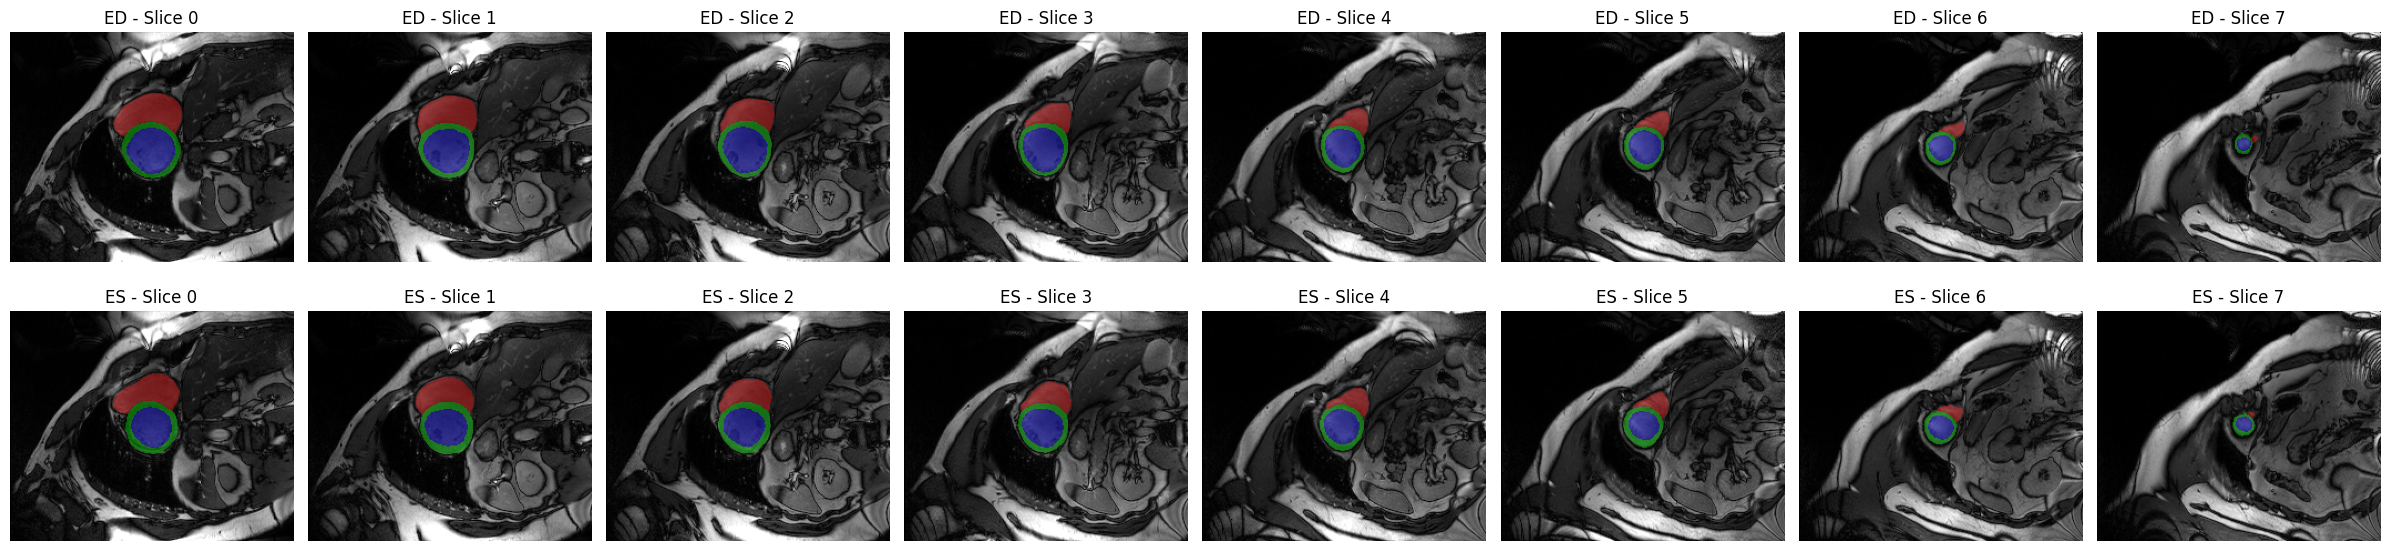

In [11]:
subject_data = nifti_train_dict[random_index]
ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)


label_cmap = mcolors.ListedColormap([
    (0.0, 0.0, 0.0, 0.0),
    (1.0, 0.0, 0.0, 0.6),
    (0.0, 1.0, 0.0, 0.6), 
    (0.0, 0.0, 1.0, 0.6) 
])


n_slices = ed_img.shape[-1]
fig, axes = plt.subplots(nrows=2, ncols=n_slices, figsize=(3*n_slices, 6))

for i in range(n_slices):
    # ED 
    axes[0, i].imshow(ed_img[:, :, i], cmap='gray', alpha=1.0)
    axes[0, i].imshow(ed_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[0, i].set_title(f"ED - Slice {i}")
    axes[0, i].axis('off')

    # ES 
    axes[1, i].imshow(es_img[:, :, i], cmap='gray', alpha=1.0)
    axes[1, i].imshow(es_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[1, i].set_title(f"ES - Slice {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

#### **Histogram:** Number of slices

All subjects have matching slice counts for ED, ES, and segmentations.



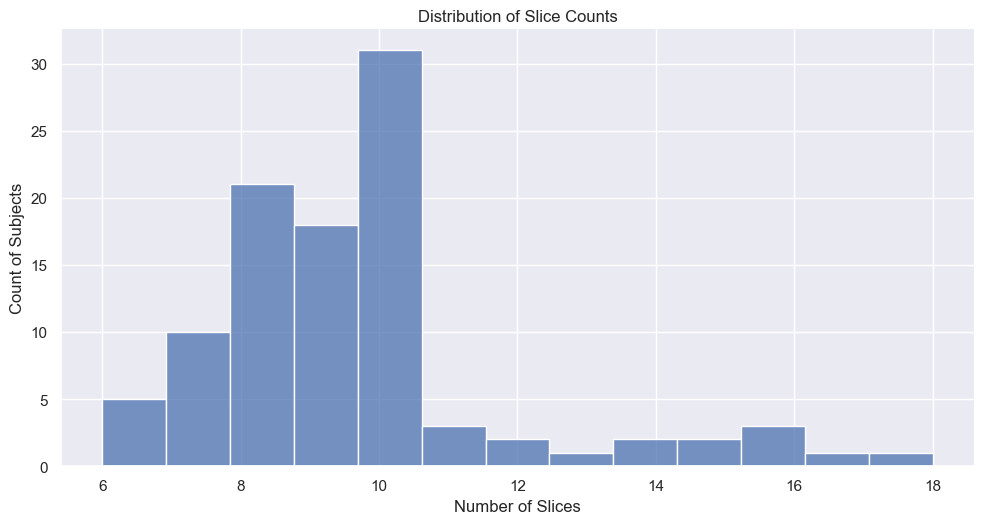

In [12]:
number_slices = []
mismatched_subjects = []

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

    n_slices = ed_img.shape[-1]
    number_slices.append(n_slices)

    if not (ed_img.shape[-1] == es_img.shape[-1] == ed_seg.shape[-1] == es_seg.shape[-1]):
        mismatched_subjects.append(subj_id)

if mismatched_subjects:
    print("Subjects with inconsistent shapes:", mismatched_subjects)
else:
    print("All subjects have matching slice counts for ED, ES, and segmentations.\n")

sns.set();
sns.displot(number_slices, bins=len(np.unique(number_slices)), aspect=2);
plt.xlabel("Number of Slices")
plt.ylabel("Count of Subjects")
plt.title("Distribution of Slice Counts")
plt.show()

#### Number of segmentated structures
Dataframe showing how many volumes contain each labeled structure (Background, Right ventricle cavity, Myocardium, Left ventricle cavity) in the ED and ES phases for both training and testing data.

In [13]:
train_ed_layer_counts = np.zeros(4, dtype=int)
train_es_layer_counts = np.zeros(4, dtype=int)
test_ed_layer_counts  = np.zeros(4, dtype=int)
test_es_layer_counts  = np.zeros(4, dtype=int)

dict_layers = {
    '0': 'Background',
    '1': 'Right ventricle cavity',
    '2': 'Myocardium',
    '3': 'Left ventricle cavity'
}

labels = [0, 1, 2, 3]
layer_names = [dict_layers[str(l)] for l in labels]

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

    # Check presence of each label in ED / ES
    unique_ed = np.unique(ed_seg)
    unique_es = np.unique(es_seg)
    
    for label in labels:
        if label in unique_ed:
            train_ed_layer_counts[label] += 1
        if label in unique_es:
            train_es_layer_counts[label] += 1

for index in list_keys_test:
    subject_data = nifti_test_dict[index]
    ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

    unique_ed = np.unique(ed_seg)
    unique_es = np.unique(es_seg)
    
    for label in labels:
        if label in unique_ed:
            test_ed_layer_counts[label] += 1
        if label in unique_es:
            test_es_layer_counts[label] += 1

data_array = [
    train_ed_layer_counts,
    train_es_layer_counts,
    test_ed_layer_counts,
    test_es_layer_counts
]

row_index = pd.MultiIndex.from_tuples(
    [
        ("Train", "ED"),
        ("Train", "ES"),
        ("Test",  "ED"),
        ("Test",  "ES")
    ],
    names=["Data Split", "Phase"]
)

df_seg_counts = pd.DataFrame(
    data=data_array,
    index=row_index,
    columns=layer_names
)

display(df_seg_counts)

Background  Right ventricle cavity  Myocardium  \
Data Split Phase                                                   
Train      ED            100                     100         100   
           ES            100                     100         100   
Test       ED             50                      50          50   
           ES             50                      50          50   

                  Left ventricle cavity  
Data Split Phase                         
Train      ED                       100  
           ES                       100  
Test       ED                         0  
           ES                         0

Based on the current data, there is **no segmentation** labeled for the **left ventricle** in any of the **test volumes**.

### Header
The most important **header fields** for this project will be:
1) [dim] = [3, 208, 174, 10, 1, 1, 1, 1]
   * dim[0]: number of dimensions
   * dim[1], dim[2], dim[3] = number of voxels along the 3 axes
2) [pixdim] = [1., 1.68269, 1.68269, 5., 1., 1., 1., 1.]
   * pixdim[1], pixdim[2], pixdim[3] give the voxel size in millimeters along the 3 axes
   * the method get_zooms() returns [pixdim[1], pixdim[2], pixdim[3]] 

In [14]:
# Train voxel dimensions
voxel_pixdim_train = []

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    ed_header, es_header, ed_seg_header, es_seg_header = get_header(subject_data)

    # Extracting voxel dimensions
    voxel_pixdims = ed_seg_header.get_zooms()
    voxel_pixdim_train.append(voxel_pixdims)

In [15]:
# Test voxel dimensions
voxel_pixdim_test = []

for index in list_keys_test:
    subject_data = nifti_test_dict[index]
    ed_header, es_header, ed_seg_header, es_seg_header = get_header(subject_data)

    # Extracting voxel dimensions
    voxel_pixdim = ed_seg_header.get_zooms()
    voxel_pixdim_test.append(voxel_pixdim)

In [16]:
# Train voxel volume
voxel_volumes_train = [d[0] * d[1] * d[2] for d in voxel_pixdim_train]
voxel_volumes_train = [vol/1000 for vol in voxel_volumes_train] # to mL

# Test voxel volume
voxel_volumes_test = [d[0] * d[1] * d[2] for d in voxel_pixdim_test]
voxel_volumes_test = [vol/1000 for vol in voxel_volumes_test] # to mL

# 4. Missing Segmentation (LV) <a name="lv-segmentation"></a>
As previously noted, the test volumes do not include LV segmentations, which must be generated in order to compute certain classification metrics.

#### Example of missing LV segmentation

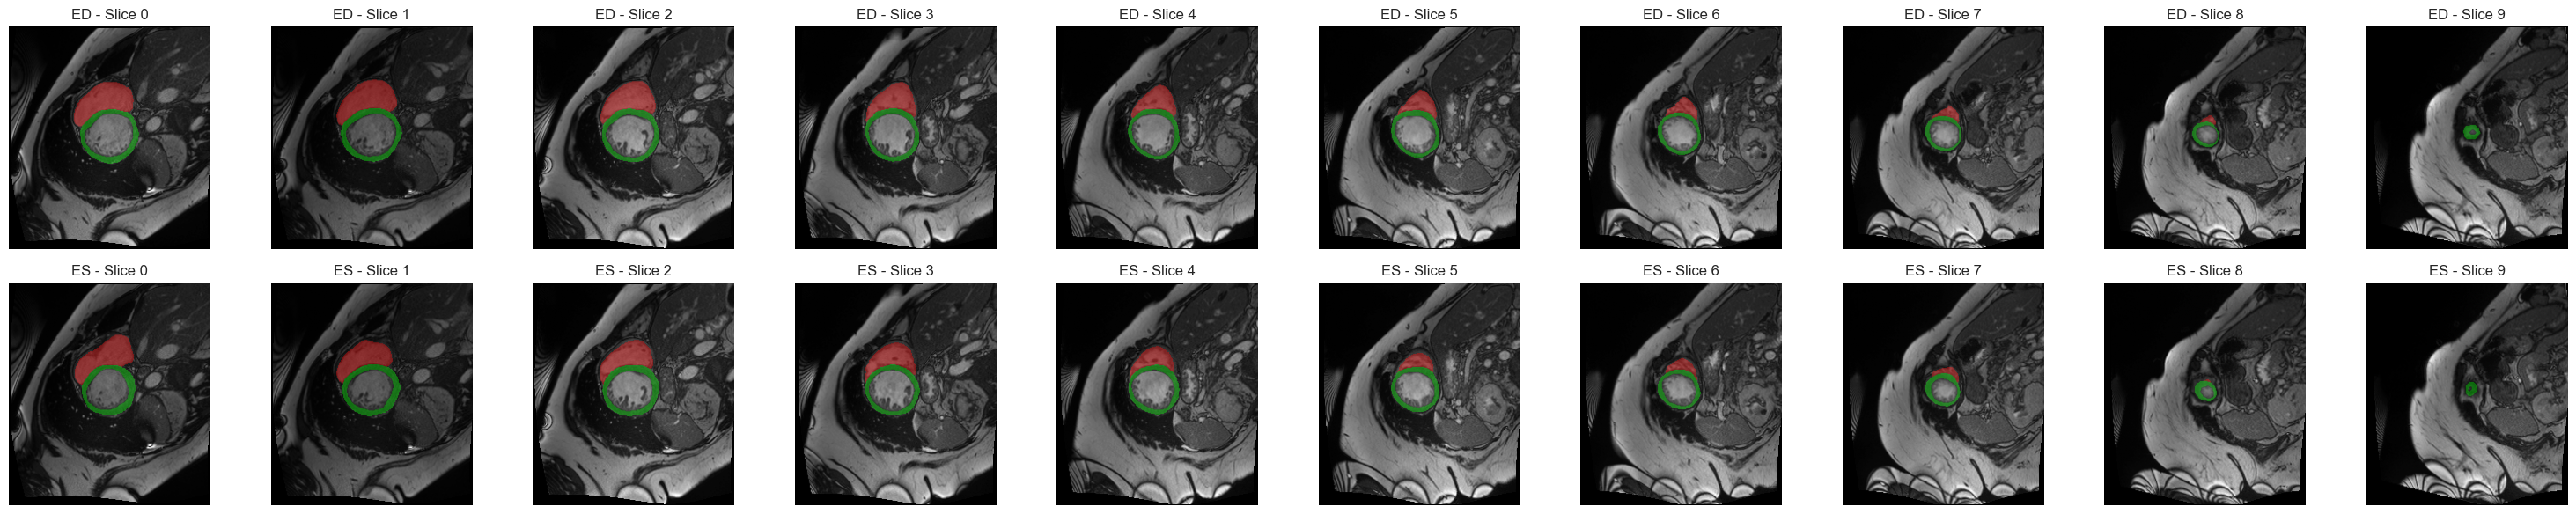

In [17]:
random_index = random.choice(list_keys_test)

subject_data = nifti_test_dict[random_index]
ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

n_slices = ed_img.shape[-1]
fig, axes = plt.subplots(nrows=2, ncols=n_slices, figsize=(3*n_slices, 6))

for i in range(n_slices):
    # ED 
    axes[0, i].imshow(ed_img[:, :, i], cmap='gray', alpha=1.0)
    axes[0, i].imshow(ed_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[0, i].set_title(f"ED - Slice {i}")
    axes[0, i].axis('off')

    # ES 
    axes[1, i].imshow(es_img[:, :, i], cmap='gray', alpha=1.0)
    axes[1, i].imshow(es_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[1, i].set_title(f"ES - Slice {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

### Hypothesis
A potential assumption is that the region enclosed by the Myocardium (green) corresponds to the Left Ventricle (LV). To evaluate this hypothesis, the Intersection over Union (IoU) will be calculated between the LV region extracted using the proposed method and the ground truth LV layer in the training data.

In [18]:
overall_imperfect = {}  # Dictionary to store imperfect slice details per subject
list_fails = []

threshold = 0.5

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    _, _, ed_seg, es_seg = get_volumetric_image(subject_data)
    
    pred_ed_seg = fill_lv_inside_myo(ed_seg, myo_label=2, lv_label=3)
    pred_es_seg = fill_lv_inside_myo(es_seg, myo_label=2, lv_label=3)
    
    num_slices = ed_seg.shape[-1]
    subject_imperfect = {"ED": [], "ES": []}

    for z in range(num_slices):
        gt_has_lv = np.any(ed_seg[..., z] == 3)
        gt_has_myo = np.any(ed_seg[..., z] == 2)
        
        if gt_has_lv or gt_has_myo:
        
            iou_lv_ed = compute_iou(pred_ed_seg[..., z], ed_seg[..., z], label=3)
            iou_lv_es = compute_iou(pred_es_seg[..., z], es_seg[..., z], label=3)
            
            if iou_lv_ed < threshold:
                subject_imperfect["ED"].append((z, iou_lv_ed))
                list_fails.append(['ED', index, z])
                
            if iou_lv_es < threshold:
                subject_imperfect["ES"].append((z, iou_lv_es))
                list_fails.append(['ES', index, z])
    
    # Only add subject if there is any imperfect slice
    if subject_imperfect["ED"] or subject_imperfect["ES"]:
        overall_imperfect[index] = subject_imperfect

# Print overall result
if not overall_imperfect:
    print("All slices have a perfect match (IoU = 1.000) for all the Train subjects.")
else:
    for index, details in overall_imperfect.items():
        print(f"\nSubject {index} results:")
        for phase in ["ED", "ES"]:
            for z, iou in details[phase]:
                print(f"  {phase} Slice {z}: IoU = {iou:.3f}")


Subject 011 results:
  ED Slice 0: IoU = 0.000

Subject 029 results:
  ED Slice 0: IoU = 0.000

Subject 045 results:
  ES Slice 0: IoU = 0.000

Subject 068 results:
  ES Slice 0: IoU = 0.000

Subject 069 results:
  ES Slice 0: IoU = 0.000

Subject 084 results:
  ES Slice 0: IoU = 0.000

Subject 096 results:
  ES Slice 1: IoU = 0.000


The code above applies a **mathematical morphology operation to fill the enclosed areas within the myocardium** (label 2) by using the function $\texttt{binary\_fill\_holes}$. This function identifies holes within the myocardium and fills them in, **reassigning those regions with the left ventricle label** (label 3). The modified segmentation is then compared to the original segmentation on the training data by calculating IoU scores. 

The output indicates that most of the cases recreated the LV region as originally labeled in the training data, but there were some cases where the $\texttt{binary\_fill\_holes}$ did not work. A further analysis will be made to understand the cause of this errors.

#### Analysis of the failures

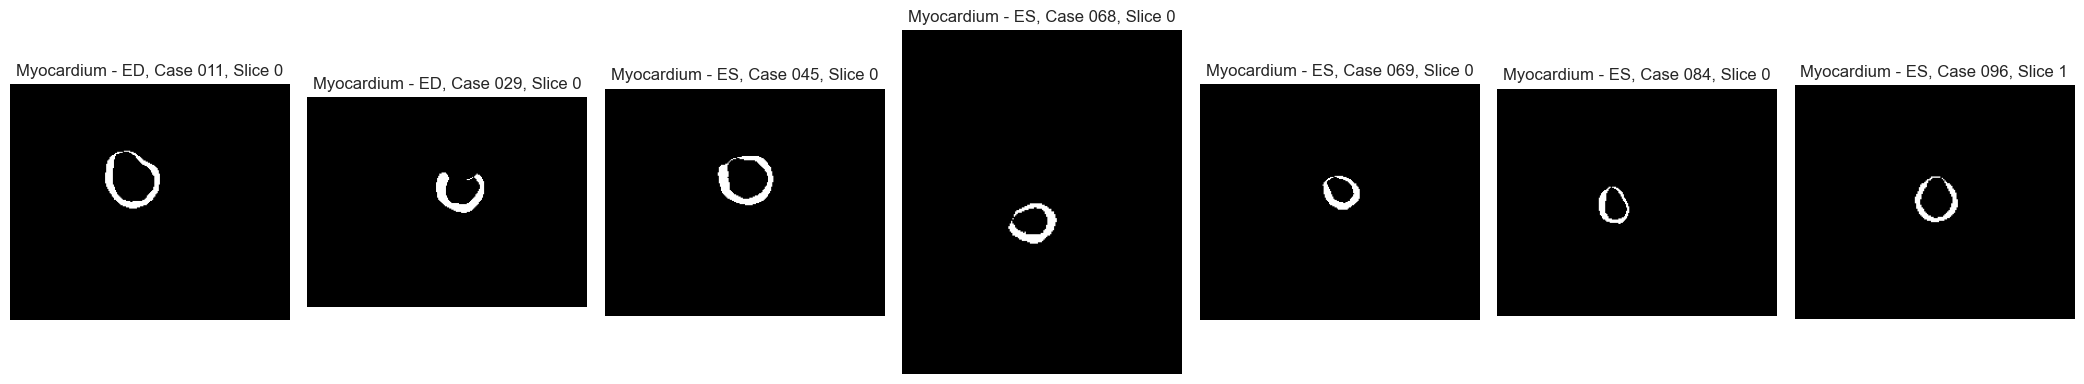

In [19]:
fig, axes = plt.subplots(ncols=len(list_fails), figsize=(3*len(list_fails), 6))

for idx, fail in enumerate(list_fails):

    chosen_data = nifti_train_dict[fail[1]]
    _, _, ed_seg, es_seg = get_volumetric_image(chosen_data)
    
    if fail[0] == 'ES':
        chosen_mask = es_seg[:, :, fail[2]]
    elif fail[0] == 'ED':
        chosen_mask = ed_seg[:, :, fail[2]]

    myo_mask = (chosen_mask == 2)

    # Plot using the corresponding subplot axis
    ax = axes[idx] if len(list_fails) > 1 else axes  # handle single-image edge case
    ax.imshow(myo_mask, cmap='gray')
    ax.set_title(f"Myocardium - {fail[0]}, Case {fail[1]}, Slice {fail[2]}")
    ax.axis('off')

plt.tight_layout()
plt.show() 

All the failure cases shown above exhibit **non-closed myocardium structures**, which prevents the use of the $\texttt{binary\_fill\_holes}$ function to correctly segment the left ventricle (LV). The function relies on completely enclosed regions to identify and fill internal areas, so gaps in the myocardial contour break this logic.

To solve this, we apply a **convex hull** to the myocardium mask to **morphologically close the gaps**. Subtracting the original mask from its convex hull creates a candidate LV region. Then, we extract the **largest connected component** to isolate the **main LV area** and eliminate noise.

#### Closing the gaps

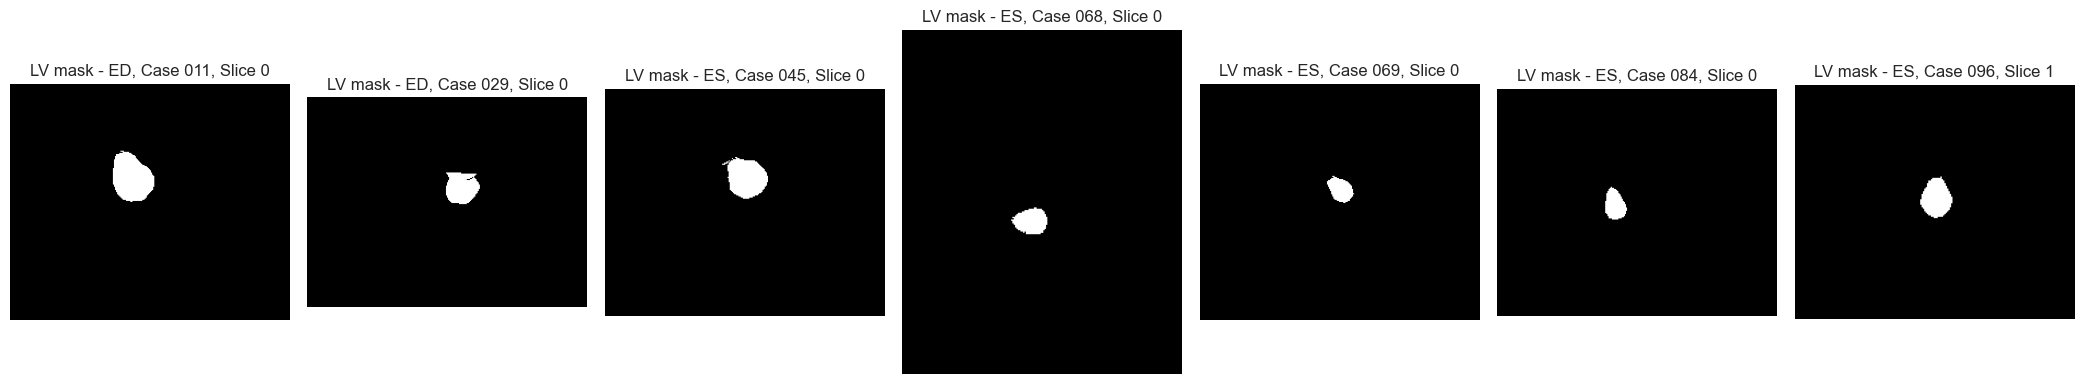

In [20]:
if len(list_fails) == 0:
    print("No failure cases to plot.")
    
else:
    fig, axes = plt.subplots(ncols=len(list_fails), figsize=(3*len(list_fails), 6))
    
    for idx, fail in enumerate(list_fails):
        chosen_data = nifti_train_dict[fail[1]]
        _, _, ed_seg, es_seg = get_volumetric_image(chosen_data)
        
        # Select the appropriate segmentation slice for ED or ES
        if fail[0] == 'ES':
            chosen_mask = es_seg[:, :, fail[2]]
        elif fail[0] == 'ED':
            chosen_mask = ed_seg[:, :, fail[2]]
    
        myo_mask = (chosen_mask == 2)
    
        # Apply morphological closing and then fill holes (using convex_hull_image)
        convex_myo = convex_hull_image(myo_mask)
        new_lv_area = convex_myo & ~myo_mask
        
        # Keep only the largest connected component in new_lv_area
        labeled_area = skimage.measure.label(new_lv_area)
        
        if labeled_area.max() > 0:
            # There is at least one connected component
            regions = regionprops(labeled_area)
            largest_region = max(regions, key=lambda r: r.area)
            largest_mask = (labeled_area == largest_region.label)
        else:
            # No connected components found; fallback is just new_lv_area
            largest_mask = new_lv_area
        
        # Plot using the corresponding subplot axis
        ax = axes[idx] if len(list_fails) > 1 else axes  # handle single-image edge case
        ax.imshow(largest_mask, cmap='gray')
        ax.set_title(f"LV mask - {fail[0]}, Case {fail[1]}, Slice {fail[2]}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

The result indicates that the proposed solution successfully closes gaps in the myocardium and fills the left ventricle region. At first, the myocardium contour was incomplete, preventing proper filling. After applying the convex hull and selecting the largest connected component, the myocardium appears fully enclosed, allowing a clear and consistent LV segmentation.

To further validate these results, we will reapply the proposed method to the entire training dataset. We will then evaluate the LV segmentation by identifying slices with an IoU below the 0.9 threshold and calculating the overall mean IoU score across all slices.

### Solution's IoU Score

For evaluating the solution’s IoU score, I added conditional checks to ensure that the metric is computed only for valid cases, specifically, slices that originally contain both LV segmentation and myocardium in the training data. This way, we focus on the cases where the solution is truly applicable.

In [21]:
overall_imperfect = {} 
list_fails = []
all_iou_scores = []

threshold = 0.9

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    _, _, ed_seg, es_seg = get_volumetric_image(subject_data)
    
    pred_ed_seg = solution_lv_inside_myo(ed_seg, myo_label=2, lv_label=3)
    pred_es_seg = solution_lv_inside_myo(es_seg, myo_label=2, lv_label=3)
    
    num_slices = ed_seg.shape[-1]
    subject_imperfect = {"ED": [], "ES": []}

    for z in range(num_slices):
        gt_has_lv_ed = np.any(ed_seg[..., z] == 3)
        gt_has_lv_es = np.any(es_seg[..., z] == 3)
        gt_has_myo_ed = np.any(ed_seg[..., z] == 2)
        gt_has_myo_es = np.any(es_seg[..., z] == 2)
        
        if (gt_has_lv_ed and gt_has_myo_ed):
        
            iou_lv_ed = compute_iou(pred_ed_seg[..., z], ed_seg[..., z], label=3)
            all_iou_scores.append(iou_lv_ed)
            
            if iou_lv_ed < threshold:
                subject_imperfect["ED"].append((z, iou_lv_ed))
                list_fails.append(['ED', index, z])

        if (gt_has_lv_es and gt_has_myo_es):
            
            iou_lv_es = compute_iou(pred_es_seg[..., z], es_seg[..., z], label=3)
            all_iou_scores.append(iou_lv_es)

            if iou_lv_es < threshold:
                subject_imperfect["ES"].append((z, iou_lv_es))
                list_fails.append(['ES', index, z])
    
    # Only add subject if there is any imperfect slice
    if subject_imperfect["ED"] or subject_imperfect["ES"]:
        overall_imperfect[index] = subject_imperfect

# Print overall result
if not overall_imperfect:
    print("All slices have a perfect match (IoU = 1.000) for all the Train subjects.")
else:
    for index, details in overall_imperfect.items():
        print(f"\nSubject {index} results:")
        for phase in ["ED", "ES"]:
            for z, iou in details[phase]:
                print(f"  {phase} Slice {z}: IoU = {iou:.3f}")

# Compute and print the mean IoU
if all_iou_scores:
    mean_iou = np.mean(all_iou_scores)
    print(f"\nMean IoU across evaluated slices: {mean_iou:.4f}")
else:
    print("\nNo slices were evaluated for IoU calculation.")


Subject 029 results:
  ED Slice 0: IoU = 0.800

Mean IoU across evaluated slices: 0.9998


---
The results are very promising, indicating that the proposed method is highly effective in segmenting the LV region in the training data. Based on these results, I’ll now apply this approach to the test data to segment the missing LVs.

### LV Segmentation

In [22]:
for index in list_keys_test:
    subject_data_test = nifti_test_dict[index]
    _, _, ed_seg_test, es_seg_test = get_volumetric_image(subject_data_test)
    
    # Create new segmentation arrays
    ed_seg_test_new = solution_lv_inside_myo(ed_seg_test, myo_label=2, lv_label=3)
    es_seg_test_new = solution_lv_inside_myo(es_seg_test, myo_label=2, lv_label=3)
    
    # Wrap the new arrays into nibabel Nifti1Image objects using the original affine and header
    subject_data_test['ED_seg'] = nib.Nifti1Image(
        ed_seg_test_new, 
        subject_data_test['ED_seg'].affine, 
        subject_data_test['ED_seg'].header
    )
    subject_data_test['ES_seg'] = nib.Nifti1Image(
        es_seg_test_new, 
        subject_data_test['ES_seg'].affine, 
        subject_data_test['ES_seg'].header
    )

#### Filled LV example

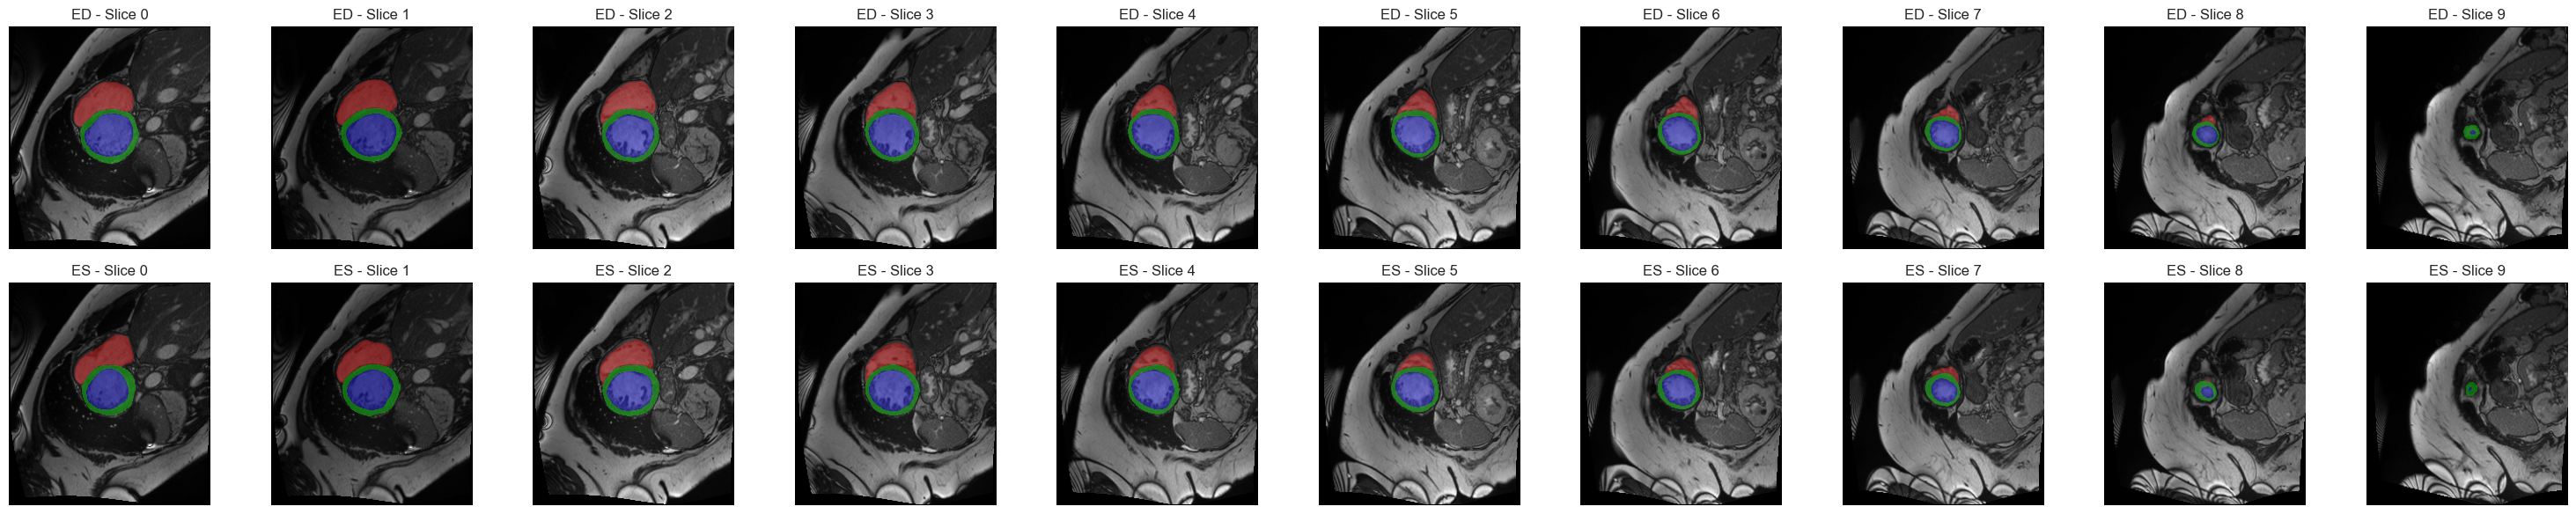

In [23]:
subject_data = nifti_test_dict[random_index]
ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

n_slices = ed_img.shape[-1]
fig, axes = plt.subplots(nrows=2, ncols=n_slices, figsize=(3*n_slices, 6))

for i in range(n_slices):
    # ED 
    axes[0, i].imshow(ed_img[:, :, i], cmap='gray', alpha=1.0)
    axes[0, i].imshow(ed_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[0, i].set_title(f"ED - Slice {i}")
    axes[0, i].axis('off')

    # ES 
    axes[1, i].imshow(es_img[:, :, i], cmap='gray', alpha=1.0)
    axes[1, i].imshow(es_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[1, i].set_title(f"ES - Slice {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# 5. Metrics and Features <a name="metrics-and-features"></a>

The features used for the analysis include:

* Body surface area (BSA)
* Anatomical Structures Volume
* Ejection Fraction (EF)
* Myocardial Thickness

In total, 13 distinct features were extracted and utilized in the model for classification.

## Body surface area (BSA)

Du Bois formula: $0.007184 \times{(weight^{0.425} \times{height^{0.725}})}$

In [24]:
def compute_bsa(df):
    
    bsa_list = []
    
    for _, row in df.iterrows():
        
        bsa = 0.007184 * (row['Weight'] ** 0.425) * (row['Height'] ** 0.725)
        bsa_list.append(bsa)

    return bsa_list

In [25]:
# Train
bsa_list_train = compute_bsa(df_metadata_train)

# Test
bsa_list_test = compute_bsa(df_metadata_test)

## Volume

Volume is a measure that represents the physical size of a region in three-dimensional space. The volume of a segmented region is calculated by multiplying the number of voxels in the region by the volume of each voxel. Mathematically, this is expressed as:

$$
V = N_{\text{voxels}} \times V_{\text{voxel}}
$$

This volume metric is applied to anatomical structures at two different time points—commonly at the end-diastole (when the ventricle is fully filled) and at the end-systole (after contraction).

### Left Ventricle

In [26]:
# Train
lv_vol_ed_train, lv_vol_es_train = compute_volume(list_keys_train, 'train', label=3)

# Test
lv_vol_ed_test, lv_vol_es_test = compute_volume(list_keys_test, 'test', label=3)

### Right Ventricle

In [27]:
# Train
rv_vol_ed_train, rv_vol_es_train = compute_volume(list_keys_train, 'train', label=1)

# Test
rv_vol_ed_test, rv_vol_es_test = compute_volume(list_keys_test, 'test', label=1)

### Myocardium

In [28]:
# Train
myo_vol_ed_train, myo_vol_es_train = compute_volume(list_keys_train, 'train', label=2)

# Test
myo_vol_ed_test, myo_vol_es_test = compute_volume(list_keys_test, 'test', label=2)

### LV, RV and Myocardium diastolic volumes $(\frac{mL}{m^2})$

$$\text{Normalized Volume} = \frac{\text{Volume at End-Diastole (mL)}}{\text{Body Surface Area (m}^2\text{)}}$$

where:
* LV, RV, and Myocardium volumes are measured at the end of diastole (ED)
* BSA is the body surface area of the subject.

In [29]:
# Train
dict_lv_diast_vol_train = {}
dict_rv_diast_vol_train = {}
dict_myo_diast_vol_train = {}

for i, index in enumerate(list_keys_train):
    dict_lv_diast_vol_train[index] = (lv_vol_ed_train[i]/bsa_list_train[i])
    dict_rv_diast_vol_train[index] = (rv_vol_ed_train[i]/bsa_list_train[i])
    dict_myo_diast_vol_train[index] = (myo_vol_ed_train[i]/bsa_list_train[i])

# Test
dict_lv_diast_vol_test = {}
dict_rv_diast_vol_test = {}
dict_myo_diast_vol_test = {}

for i, index in enumerate(list_keys_test):
    dict_lv_diast_vol_test[index] = (lv_vol_ed_test[i]/bsa_list_test[i])
    dict_rv_diast_vol_test[index] = (rv_vol_ed_test[i]/bsa_list_test[i])
    dict_myo_diast_vol_test[index] = (myo_vol_ed_test[i]/bsa_list_test[i])

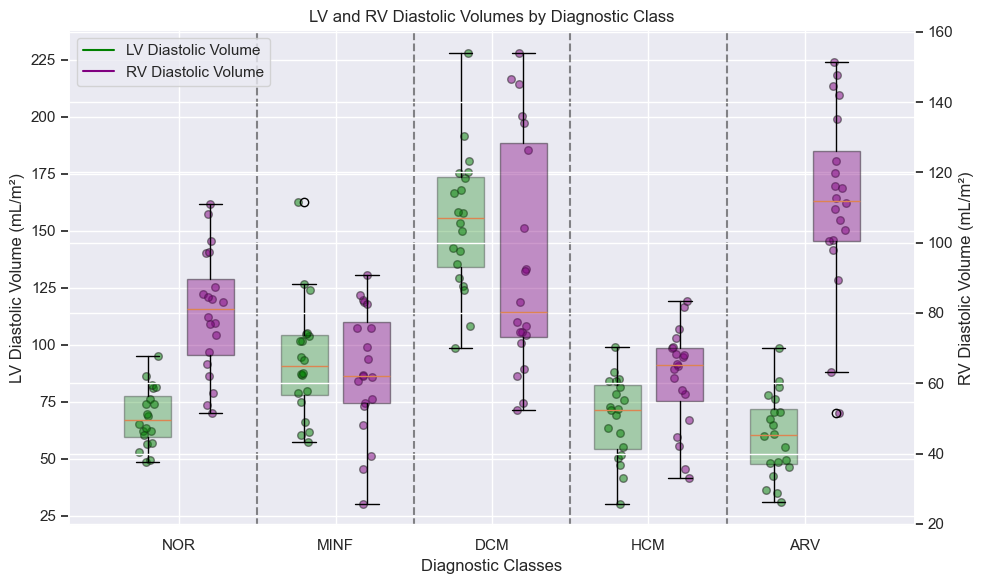

In [30]:
cat_mapping = {
    0: "NOR",   # Healthy controls
    1: "MINF",  # Myocardial infarction
    2: "DCM",   # Dilated cardiomyopathy
    3: "HCM",   # Hypertrophic cardiomyopathy
    4: "ARV"    # Abnormal right ventricle
}

cats = sorted(cat_mapping.keys())
xvals = np.arange(len(cats))
xlabels = [cat_mapping[c] for c in cats]

# Group LV and RV diastolic volumes by diagnostic class
lv_volumes_data = []
rv_volumes_data = []

for c in cats:
    # Select rows corresponding to the current category
    cat_rows = df_metadata_train[df_metadata_train['Category'] == c]
    # Convert Ids to three-digit strings (e.g., "001")
    subject_ids = cat_rows['Id'].apply(lambda x: f"{int(x):03d}").values
    # Gather LV and RV diastolic volumes for subjects that are present in the dictionaries
    lv_vols = [dict_lv_diast_vol_train[subid] for subid in subject_ids if subid in dict_lv_diast_vol_train]
    rv_vols = [dict_rv_diast_vol_train[subid] for subid in subject_ids if subid in dict_rv_diast_vol_train]
    
    lv_volumes_data.append(lv_vols)
    rv_volumes_data.append(rv_vols)

# Plotting the boxplots with LV volumes on one y-axis and RV volumes on the other
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()  # Secondary y-axis for RV volumes

offset = 0.2

# LV diastolic volumes boxplot (shifted left)
bp_lv = ax1.boxplot(
    lv_volumes_data,
    positions=xvals - offset,
    widths=0.3,
    patch_artist=True)
for patch in bp_lv['boxes']:
    patch.set_facecolor('green')
    patch.set_alpha(0.3)

# Scatter individual LV data points with jitter
for i, lv_vols in enumerate(lv_volumes_data):
    x_jitter = np.random.normal(loc=xvals[i] - offset, scale=0.03, size=len(lv_vols))
    ax1.scatter(x_jitter, lv_vols, color='green', edgecolors='k', alpha=0.5, s=30)

# RV diastolic volumes boxplot (shifted right)
bp_rv = ax2.boxplot(
    rv_volumes_data,
    positions=xvals + offset,
    widths=0.3,
    patch_artist=True)
for patch in bp_rv['boxes']:
    patch.set_facecolor('purple')
    patch.set_alpha(0.4)

# Scatter individual RV data points with jitter
for i, rv_vols in enumerate(rv_volumes_data):
    x_jitter = np.random.normal(loc=xvals[i] + offset, scale=0.03, size=len(rv_vols))
    ax2.scatter(x_jitter, rv_vols, color='purple', edgecolors='k', alpha=0.5, s=30)

# Set x-axis tick labels to the diagnostic class acronyms
ax1.set_xticks(xvals)
ax1.set_xticklabels(xlabels)
for boundary in xvals[1:]:
    ax1.axvline(boundary - 0.5, color='k', linestyle='--', alpha=0.5)

ax1.set_xlabel('Diagnostic Classes')
ax1.set_ylabel('LV Diastolic Volume (mL/m²)')
ax2.set_ylabel('RV Diastolic Volume (mL/m²)')
ax1.set_title('LV and RV Diastolic Volumes by Diagnostic Class')

# Dummy lines for legend entries
ax1.plot([], c='green', label='LV Diastolic Volume')
ax1.plot([], c='purple', label='RV Diastolic Volume')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

The boxplot results are in line with the diagnostic criteria described in [1]. For example, the **NOR** group, **LV diastolic volumes remain below 90 mL/m²** and **RV volumes are under 100 mL/m²**. By contrast, the **MINF** group shows **larger LV volumes**, a sign of post-infarction remodeling. The **DCM** group is characterized by **LV diastolic volumes above 100 mL/m²**, while the **ARV** group exhibits **significantly elevated RV volumes, exceeding 100 mL/m²** and **normal LV diastolic volumes**.

## Ejection Fraction

Ejection fraction (EF) is a measure of the heart’s pumping efficiency and is typically defined for a ventricle as:

$$EF = \frac{(EDV – ESV)}{EDV}$$

where:
* EDV (End-Diastolic Volume): The maximum volume of the ventricle when it is fully filled.
* ESV (End-Systolic Volume): The minimum volume of the ventricle after contraction.

### Left Ventricle (LVEF) and Right Ventricle (RVEF)

In [31]:
lv_ef_train = {}
rv_ef_train = {}
lv_ef_test = {}
rv_ef_test = {}

# Train
for i, index in enumerate(list_keys_train):
    lv_ef_train[index] = (lv_vol_ed_train[i]-lv_vol_es_train[i])/(lv_vol_ed_train[i])
    rv_ef_train[index] = (rv_vol_ed_train[i]-rv_vol_es_train[i])/(rv_vol_ed_train[i])
    
# Test 
for i, index in enumerate(list_keys_test):
    lv_ef_test[index] = (lv_vol_ed_test[i]-lv_vol_es_test[i])/(lv_vol_ed_test[i])
    rv_ef_test[index] = (rv_vol_ed_test[i]-rv_vol_es_test[i])/(rv_vol_ed_test[i])

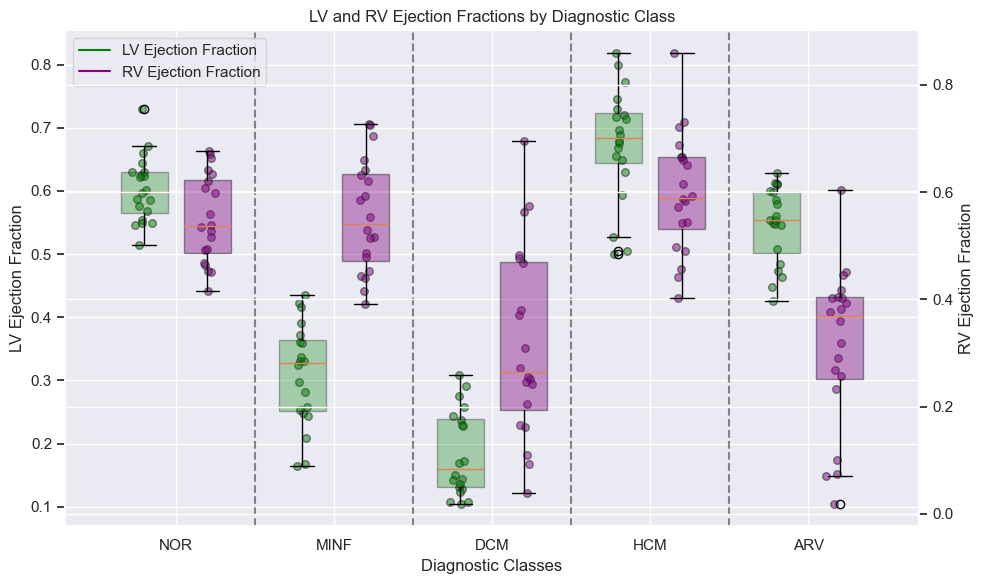

In [32]:
# Define the sorted diagnostic categories and corresponding labels
cats = sorted(cat_mapping.keys())
xvals = np.arange(len(cats))
xlabels = [cat_mapping[c] for c in cats]

# Group LV and RV ejection fractions by diagnostic class using training metadata and EF dictionaries
lv_ef_data = []
rv_ef_data = []

for c in cats:
    # Select subjects in the current category and format Ids as three-digit strings
    subject_ids = df_metadata_train.loc[df_metadata_train['Category'] == c, 'Id'].apply(lambda x: f"{int(x):03d}").values
    # Retrieve EF values from the dictionaries if available
    lv_efs = [lv_ef_train[subid] for subid in subject_ids if subid in lv_ef_train]
    rv_efs = [rv_ef_train[subid] for subid in subject_ids if subid in rv_ef_train]
    
    lv_ef_data.append(lv_efs)
    rv_ef_data.append(rv_efs)

# Create the plot with two y-axes (one for LV EF and one for RV EF)
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()  # Secondary axis for RV EF

offset = 0.2  # Offset to separate the boxplots

# Plot LV ejection fractions as a boxplot (shifted left)
bp_lv = ax1.boxplot(
    lv_ef_data,
    positions=xvals - offset,
    widths=0.3,
    patch_artist=True)
for patch in bp_lv['boxes']:
    patch.set_facecolor('green')
    patch.set_alpha(0.3)

# Scatter individual LV EF data points with jitter
for i, lv_efs in enumerate(lv_ef_data):
    x_jitter = np.random.normal(loc=xvals[i] - offset, scale=0.03, size=len(lv_efs))
    ax1.scatter(x_jitter, lv_efs, color='green', edgecolors='k', alpha=0.5, s=30)

# Plot RV ejection fractions as a boxplot (shifted right)
bp_rv = ax2.boxplot(
    rv_ef_data,
    positions=xvals + offset,
    widths=0.3,
    patch_artist=True)
for patch in bp_rv['boxes']:
    patch.set_facecolor('purple')
    patch.set_alpha(0.4)

# Scatter individual RV EF data points with jitter
for i, rv_efs in enumerate(rv_ef_data):
    x_jitter = np.random.normal(loc=xvals[i] + offset, scale=0.03, size=len(rv_efs))
    ax2.scatter(x_jitter, rv_efs, color='purple', edgecolors='k', alpha=0.5, s=30)

# Set x-axis ticks and labels for the diagnostic classes
ax1.set_xticks(xvals)
ax1.set_xticklabels(xlabels)
# Add vertical dashed lines between categories for clarity
for boundary in xvals[1:]:
    ax1.axvline(boundary - 0.5, color='k', linestyle='--', alpha=0.5)

ax1.set_xlabel('Diagnostic Classes')
ax1.set_ylabel('LV Ejection Fraction')
ax2.set_ylabel('RV Ejection Fraction')
ax1.set_title('LV and RV Ejection Fractions by Diagnostic Class')

# Add dummy lines for the legend entries
ax1.plot([], c='green', label='LV Ejection Fraction')
ax1.plot([], c='purple', label='RV Ejection Fraction')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

The boxplot results are in line with the diagnostic criteria described in [1]. For example, the **NOR** group displays **LV ejection fractions well above 50% and RV ejection fractions above 40%**, indicative of normal systolic function. By contrast, the **MINF** group exhibits markedly reduced **LV ejection fractions (below 40%)**, consistent with systolic heart failure post-infarction. The **DCM** group also shows **LV ejection fractions below 40%**, reflecting dilated cardiomyopathy. In contrast, the **HCM** group maintains **LV ejection fractions above 55%**, aligning with hypertrophic cardiomyopathy’s preserved systolic function. Finally, the **ARV** group shows **normal LV ejection fractions** but significantly **decreased RV ejection fractions (below 40%)**, confirming the right ventricular dysfunction characteristic of arrhythmogenic right ventricular cardiomyopathy.

## Thickness of the Cardiac Muscle
This measurement is typically obtained at end-diastole, the phase of the cardiac cycle when the heart is filled and myocardium thickness is most clearly standardized for clinical reference.

### Mean and Maximum Diastolic Thickness

In [33]:
# Train
mean_thickness_train, max_thickness_train = compute_myo_thickness(data_part='train')

# Test
mean_thickness_test, max_thickness_test = compute_myo_thickness(data_part='test')

# 6. Model <a name="model"></a>

## Data

#### Adding features

In [34]:
# Height and Weight
df_train = df_metadata_train.copy()
df_test = df_metadata_test.copy()

# Volumes
df_train['LV_volume_ED'] = lv_vol_ed_train
df_train['LV_volume_ES'] = lv_vol_es_train
df_train['RV_volume_ED'] = rv_vol_ed_train
df_train['RV_volume_ES'] = rv_vol_es_train
df_train['MYO_volume_ED'] = myo_vol_ed_train
df_train['MYO_volume_ES'] = myo_vol_es_train
df_train['RV_diastolic_vol'] = list(dict_rv_diast_vol_train.values())
df_train['LV_diastolic_vol'] = list(dict_lv_diast_vol_train.values())
df_train['MYO_diastolic_vol'] = list(dict_myo_diast_vol_train.values())

df_test['LV_volume_ED'] = lv_vol_ed_test
df_test['LV_volume_ES'] = lv_vol_es_test
df_test['RV_volume_ED'] = rv_vol_ed_test
df_test['RV_volume_ES'] = rv_vol_es_test
df_test['MYO_volume_ED'] = myo_vol_ed_test
df_test['MYO_volume_ES'] = myo_vol_es_test
df_test['RV_diastolic_vol'] = list(dict_rv_diast_vol_test.values())
df_test['LV_diastolic_vol'] = list(dict_lv_diast_vol_test.values())
df_test['MYO_diastolic_vol'] = list(dict_myo_diast_vol_test.values())

# Volume Ratios
df_train['RV/LV_vol_ED'] = df_train['RV_volume_ED'] / df_train['LV_volume_ED']
df_train['RV/LV_vol_ES'] = df_train['RV_volume_ES'] / df_train['LV_volume_ES']
df_train['MYO/LV_vol_ED'] = df_train['MYO_volume_ED'] / df_train['LV_volume_ED']
df_train['MYO/LV_vol_ES'] = df_train['MYO_volume_ES'] / df_train['LV_volume_ES']

df_test['RV/LV_vol_ED'] = df_test['RV_volume_ED'] / df_test['LV_volume_ED']
df_test['RV/LV_vol_ES'] = df_test['RV_volume_ES'] / df_test['LV_volume_ES']
df_test['MYO/LV_vol_ED'] = df_test['MYO_volume_ED'] / df_test['LV_volume_ED']
df_test['MYO/LV_vol_ES'] = df_test['MYO_volume_ES'] / df_test['LV_volume_ES']

# Ejection Fraction
df_train['RV_diastolic_vol'] = list(rv_ef_train.values())
df_train['LV_diastolic_vol'] = list(lv_ef_train.values())

df_test['RV_diastolic_vol'] = list(rv_ef_test.values())
df_test['LV_diastolic_vol'] = list(lv_ef_test.values())

# Myocardium Maximum Thickness
df_train['Max_thickness'] = max_thickness_train
df_test['Max_thickness'] = max_thickness_test

#### Train

In [35]:
df_train.head()

,Id,Category,Height,Weight,LV_volume_ED,LV_volume_ES,RV_volume_ED,RV_volume_ES,MYO_volume_ED,MYO_volume_ES,RV_diastolic_vol,LV_diastolic_vol,MYO_diastolic_vol,RV/LV_vol_ED,RV/LV_vol_ES,MYO/LV_vol_ED,MYO/LV_vol_ES,Max_thickness
0,1,2,184.0,95.0,295.507812,225.610352,139.721680,59.545898,164.257812,195.068359,0.573825,0.236533,75.272139,0.472819,0.263932,0.555849,0.864625,12.597278
1,2,2,160.0,70.0,265.744400,188.303375,94.432068,28.823090,160.433578,192.565155,0.694774,0.291412,92.635040,0.355349,0.153067,0.603714,1.022633,13.671875
2,3,2,165.0,77.0,276.708984,241.088867,192.333984,174.584961,191.845703,201.074219,0.092282,0.128728,104.028260,0.695077,0.724152,0.693312,0.834025,13.441133
3,4,2,159.0,46.0,260.847092,226.472473,106.264114,84.543991,168.452454,174.957275,0.204398,0.131781,116.795477,0.407381,0.373308,0.645790,0.772532,11.022618
4,5,2,165.0,77.0,290.797119,224.094727,170.463867,74.553223,201.392578,232.261963,0.562645,0.229378,109.205050,0.586195,0.332686,0.692554,1.036445,12.734135


#### Test

In [36]:
df_test.head()

,Id,Height,Weight,LV_volume_ED,LV_volume_ES,RV_volume_ED,RV_volume_ES,MYO_volume_ED,MYO_volume_ES,RV_diastolic_vol,LV_diastolic_vol,MYO_diastolic_vol,RV/LV_vol_ED,RV/LV_vol_ES,MYO/LV_vol_ED,MYO/LV_vol_ES,Max_thickness
0,101,170.0,70.0,106.996329,29.591448,125.548823,66.850672,98.160759,126.606447,0.467532,0.723435,54.241220,1.173394,2.259121,0.917422,4.278481,13.685307
1,102,162.0,60.0,137.339270,51.787141,233.212020,117.958025,81.517320,79.775981,0.494203,0.622925,49.804766,1.698072,2.277747,0.593547,1.540459,10.642266
2,103,185.0,104.0,111.110092,41.987457,138.266159,75.598312,118.024445,132.354492,0.453241,0.622109,51.840236,1.244407,1.800498,1.062230,3.152239,15.089506
3,104,158.0,56.0,117.834907,29.776492,115.461012,53.440673,80.413352,98.245601,0.537154,0.747303,51.517590,0.979854,1.794727,0.682424,3.299435,9.953293
4,105,164.0,64.0,241.516846,210.251953,228.722168,158.677734,117.841553,120.372803,0.306242,0.129452,69.429471,0.947024,0.754703,0.487923,0.572517,10.709681


#### Dropping columns

In [37]:
X_train = df_train.drop(columns=['Id', 'Category', 'Height', 'Weight', 'MYO_volume_ES'])
y_train = df_train['Category']

X_test = df_test.drop(columns=['Id', 'Height', 'Weight', 'MYO_volume_ES'])

In [38]:
# Shuffling
X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [39]:
print(f'Number of features: {X_train.shape[1]}')

Number of features: 13


#### Scaling

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

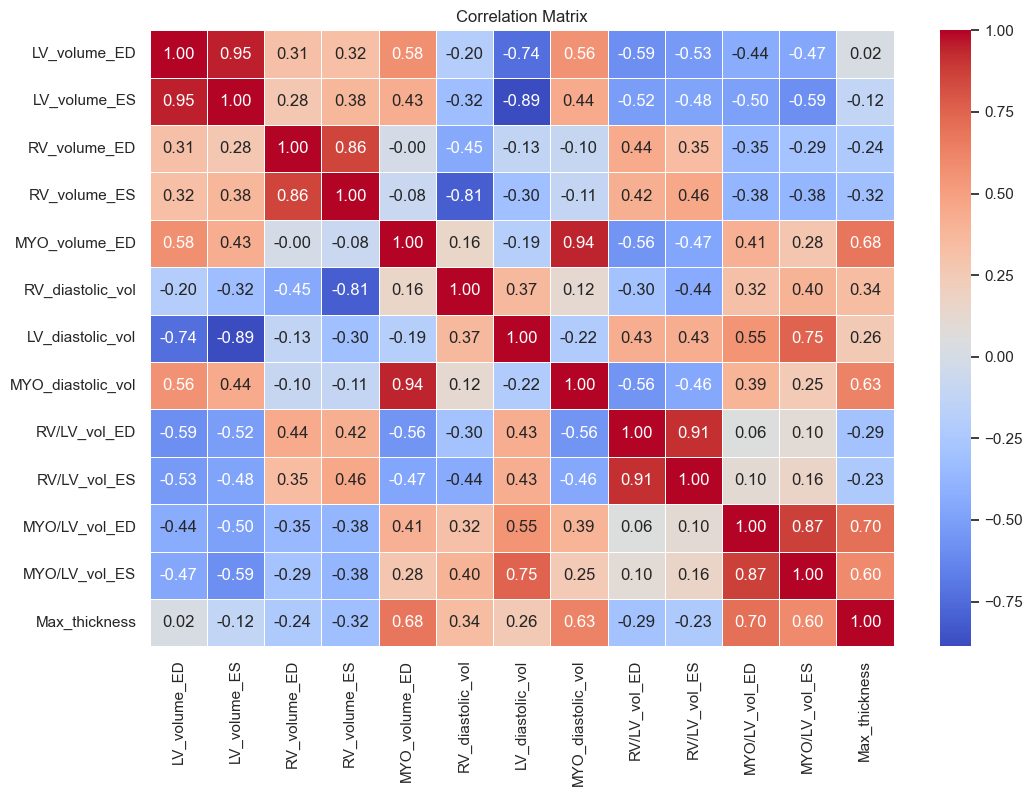

In [41]:
correlation_matrix = X_train.corr()

plt.figure(figsize=(12, 8))  # Adjust the size of the plot if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## Random Forest

### Cross-validated hyperparameter tuning

In [42]:
# RandomForest classifier
rf = RandomForestClassifier(random_state=0)

# Hyperparameters to tune
cv_params = {'max_depth': [2, 3, 4, 5, None], 
             'min_samples_leaf': [1, 2, 3],
             'min_samples_split': [2, 3, 4],
             'max_features': [2, 3, 4],
             'n_estimators': [75, 100, 125, 150]}

# Scoring metrics for multiclass classification
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',  
    'recall': 'recall_weighted',        
    'f1': 'f1_weighted'                 
}

# GridSearchCV
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='accuracy')

# Fit the model with the training data
rf_cv.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [2, 3, 4, 5, None],
                         'max_features': [2, 3, 4],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [75, 100, 125, 150]},
             refit='accuracy',
             scoring={'accuracy': 'accuracy', 'f1': 'f1_weighted',
                      'precision': 'precision_weighted',
                      'recall': 'recall_weighted'})

In [43]:
best_params_df = pd.DataFrame(rf_cv.best_params_.items(), columns=['Parameter', 'Value'])

# Display the DataFrame
display(best_params_df)
print("\nBest Score:", rf_cv.best_score_)

,Parameter,Value
0,max_depth,4
1,max_features,2
2,min_samples_leaf,1
3,min_samples_split,2
4,n_estimators,75



Best Score: 0.96


### Feature importance

In [44]:
model = rf_cv.best_estimator_

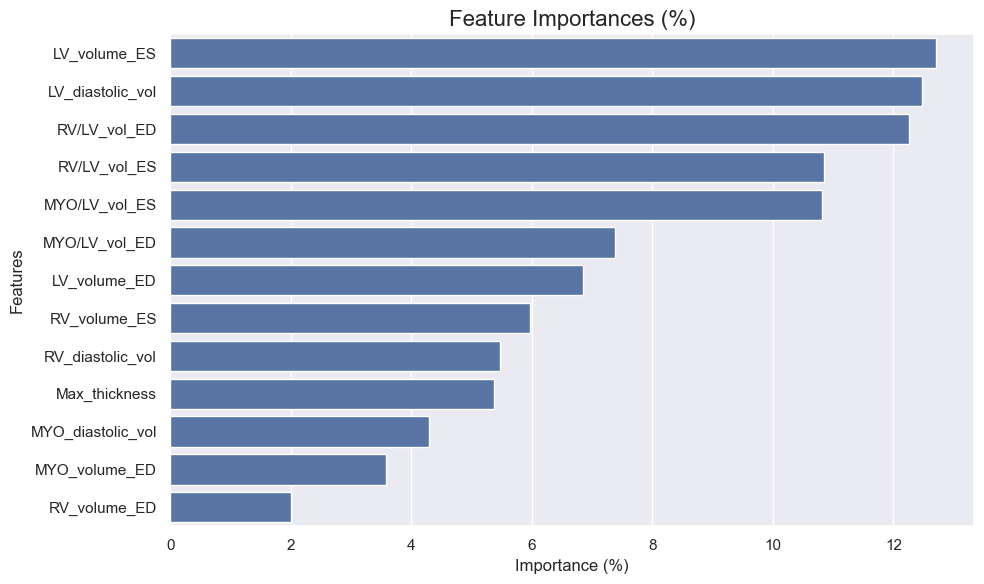

In [45]:
feature_scores = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores_percentage = feature_scores * 100
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_scores_percentage.values, y=feature_scores_percentage.index)

plt.title('Feature Importances (%)', fontsize=16)
plt.xlabel('Importance (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

### Confusion Matrix (Cross Validation)

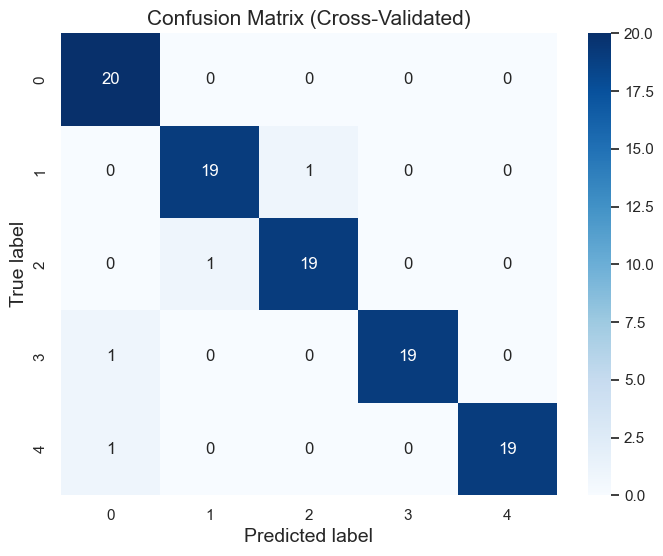

In [46]:
y_train_cv_pred = cross_val_predict(model, X_train_scaled, y_train, cv=5)

cm_cv = confusion_matrix(y_train, y_train_cv_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)

plt.title('Confusion Matrix (Cross-Validated)', fontsize=15)
plt.xlabel('Predicted label', fontsize=14)
plt.ylabel('True label', fontsize=14)
plt.show()

### Test 

In [47]:
y_pred = model.predict(X_test_scaled)

In [48]:
df_sample_submission['Category'] = y_pred

In [49]:
df_sample_submission.to_csv("Dataset/SampleSubmission.csv", index=False)

# 8. References <a name="ref"></a>

[1] Bernard, O., Lalande, A., Zotti, C., Cervenansky, F., Yang, X., Heng, P. A., & Jodoin, P. M. (2018). Deep learning techniques for automatic MRI cardiac multi-structures segmentation and diagnosis: Is the problem solved? IEEE Transactions on Medical Imaging, 37(11), 2514–2525. (https://www.creatis.insa-lyon.fr/Challenge/acdc/files/tmi_2018_bernard.pdf)

[2] Wolterink, J. M., Leiner, T., Viergever, M. A., & Išgum, I. (n.d.). Automatic segmentation and disease classification using cardiac cine MR images. Image Sciences Institute, University Medical Center Utrecht; Department of Radiology, University Medical Center Utrecht.

Citation: This work uses data from the ACDC challenge.
Bernard, O. et al. (2018). Deep Learning Techniques for Automatic MRI Cardiac Multi-structures Segmentation and Diagnosis: Is the Problem Solved?
IEEE Transactions on Medical Imaging, 37(11), 2514–2525. doi: 10.1109/TMI.2018.2837502